* ### Static frameworks such as Theano, Caffe, and TensorFlow require the computational graph to be first declared, compiled, and then executed.
* ### This leads to very efficient implementations (in production and mobile settings), it can become very painful during research and development.
* ### Modern frameworks such as Chainer, DyNet, and PyTorch implement dynamic computational graphs. These are more flexible, and provide imperative style of coding.
* ### We do not need to compile the models before every execution.
* ### __PyTorch is a library (framework) which is optimized for tensor manipulation, and it provides a series of packages for deep learning.__
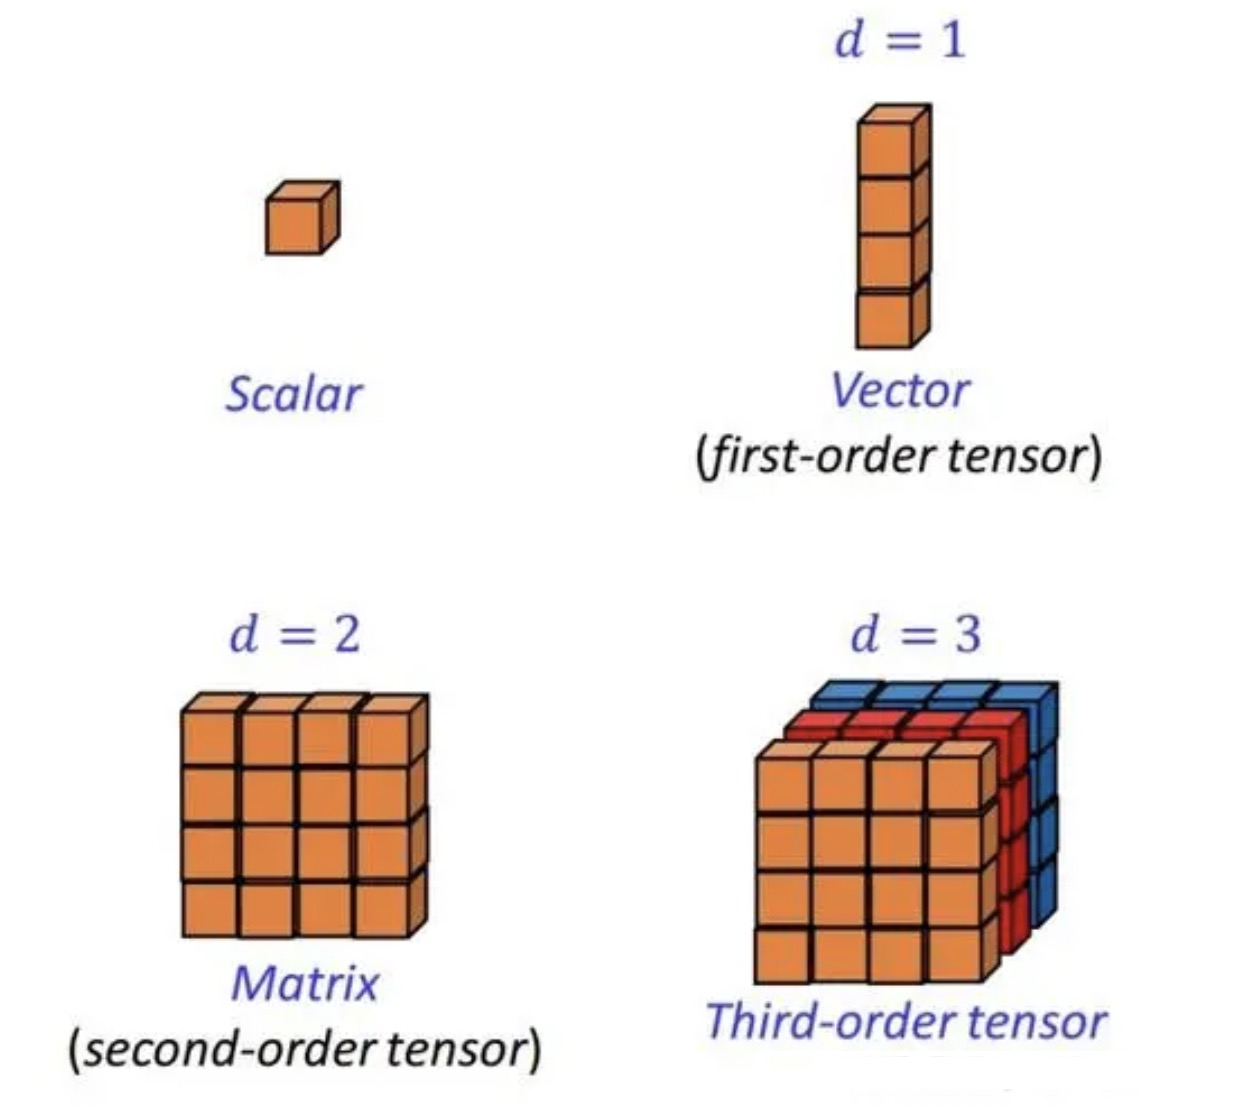

## __Modules and packages in Pytorch__
* ### __torch :__  a Tensor library like Numpy, with strong GPU support
* ### __torch.autograd :__ an automatic differentiation library that supports all differentiable Tensor operations in torch
    * e.g. loss.backward()
* ### __torch.nn :__ a neural networks library integrated with autograd
    * e.g. nn.Conv2d, nn.MaxPool2d
* ### __torch.nn.functional :__ implementation of many useful mathematical functions such as Relu, Tanh, and so on.
* ### __torch.optim :__ an optimization package to be used with torch.nn with standard optimization methods such as SGD, RMSProp, Adam, and so on.
* ### __torch.utils :__ DataLoader, Trainer and other utility functions for convenience

## __Importing modules and packages__

### how to install pytorch
https://pytorch.org/get-started/locally/

In [ ]:
import torch
import torch.nn.functional as F
import torch.nn as nn
import numpy as np

## __Diffferent level of abstractions__
* ### __Tensor:__ Like array in Numpy, but runs on a GPU to accelerate computing
* ### __Module:__ A neural network layer --> storing states or learnable weights

## __Getting started with Tensors__
https://pytorch.org/docs/stable/tensors.html

## Constructing tensor directly using torch makes the data type as (default data type):
* ### 32-bit floating point
* ### torch.float32 or torch.float
* ### torch.FloatTensor

## Construct a 5x3 matrix, uninitialized:

In [ ]:
x = torch.empty(5, 3)

In [ ]:
print(x)
x.type()

tensor([[-1.9089e+03,  4.5911e-41,  1.2926e-29],
        [ 3.0802e-41,  1.2691e-29,  3.0802e-41],
        [ 7.0065e-44,  4.5909e-41,  0.0000e+00],
        [ 0.0000e+00,  1.5330e-42,  3.0802e-41],
        [ 1.2691e-29,  3.0802e-41,  7.0065e-44]])


'torch.FloatTensor'

## Construct a 2x3 matrix, uninitialized

In [ ]:
x = torch.Tensor(2, 3)
x
# x.type()

tensor([[-1.9089e+03,  4.5911e-41,  1.2076e-29],
        [ 3.0802e-41,         nan,  0.0000e+00]])

## Construct a a randomly (uniform distribution on the interval [0, 1]) initialized $5\times 3$:

In [ ]:
x = torch.rand(5, 3)

In [ ]:
x

tensor([[0.1131, 0.7137, 0.3733],
        [0.3445, 0.7202, 0.8256],
        [0.6186, 0.8223, 0.7440],
        [0.5700, 0.2147, 0.0987],
        [0.4435, 0.9877, 0.4061]])

## Construct a a randomly (Nomral distribution) initialized $5\times 3$:

In [ ]:
x = torch.randn(5, 3)
x

tensor([[-0.6672, -1.0235, -2.3381],
        [ 1.0559, -1.1687, -0.6846],
        [ 1.6967,  1.2786, -1.0745],
        [-0.2285,  0.8003, -0.3045],
        [-0.4063, -1.0012, -0.1263]])

## Construct a zero matrix and of dtype long:

In [ ]:
x = torch.zeros(5, 3)
print(x)
print(x.type())

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])
torch.FloatTensor


In [ ]:
x = torch.zeros(5, 3, dtype=torch.long)
print(x)
print(x.type())

tensor([[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]])
torch.LongTensor


## Construct a tensor from data (a 3-d tensor):

In [ ]:
x = torch.tensor([[[5.5, 3], [-3.8, 100]], [[1, 30], [023.8, 10]]])
print(x)
print(x.type())

tensor([[[  5.5000,   3.0000],
         [ -3.8000, 100.0000]],

        [[  1.0000,  30.0000],
         [ 23.8000,  10.0000]]])
torch.FloatTensor


In [ ]:
x = torch.tensor([[[5., 3], [-3, 100]], [[1, 30], [0, 10]]])
print(x)
print(x.type())

tensor([[[  5.,   3.],
         [ -3., 100.]],

        [[  1.,  30.],
         [  0.,  10.]]])
torch.FloatTensor


## The size or shape of a tensor

In [ ]:
print(x.size())
print('*'*40)
x.shape

torch.Size([2, 2, 2])
****************************************


torch.Size([2, 2, 2])

## Construct a tensor based on an existing tensor:

###  Creating a filled tensor
* ### Any PyTorch method with an underscore (_) means an in-place operation (it modifies the content without creating a new object).

In [ ]:
x = torch.ones(2, 3)
x.fill_(5)
# x = x * 5
x

tensor([[5., 5., 5.],
        [5., 5., 5.]])

###  Reusing the properties of the input tensor, e.g. dtype, unless new values are provided by user
* ### Construcitng tensor from list makes data type as __torch.FloatTensor (float32)__ or __torch.Longtensor (signed int64)__

In [ ]:
def describe(x):
    print("Type: {}".format(x.type()))
    print("Shape/size: {}".format(x.shape))
    print("Values: \n{}".format(x))

c = [[1., 1., 1.]]*3
c1 = torch.tensor(c)
describe(c1)
print('*'*40)

cc = [[1, 1, 1]]*3
cc1 = torch.tensor(cc)
describe(cc1)
print('*'*40)

d = torch.ones((3,3))
describe(d)

Type: torch.FloatTensor
Shape/size: torch.Size([3, 3])
Values: 
tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])
****************************************
Type: torch.LongTensor
Shape/size: torch.Size([3, 3])
Values: 
tensor([[1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]])
****************************************
Type: torch.FloatTensor
Shape/size: torch.Size([3, 3])
Values: 
tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])


### Changing the data type of a tensor in different ways:

https://pytorch.org/docs/stable/tensors.html?highlight=tensor#torch.Tensor

In [ ]:
x = torch.ones(1,5)
y = torch.randn_like(x)
z = torch.randn_like(x, dtype=torch.double)
t = y.long()


In [ ]:
describe(x)
print('*'*40)
describe(y)
print('*'*40)
describe(z)
print('*'*40)
describe(t)

Type: torch.FloatTensor
Shape/size: torch.Size([1, 5])
Values: 
tensor([[1., 1., 1., 1., 1.]])
****************************************
Type: torch.FloatTensor
Shape/size: torch.Size([1, 5])
Values: 
tensor([[ 0.9220, -1.7360, -0.8921,  0.2166, -1.3473]])
****************************************
Type: torch.DoubleTensor
Shape/size: torch.Size([1, 5])
Values: 
tensor([[ 1.1869, -0.4886, -1.2363, -0.0048,  0.6222]], dtype=torch.float64)
****************************************
Type: torch.LongTensor
Shape/size: torch.Size([1, 5])
Values: 
tensor([[ 0, -1,  0,  0, -1]])


# Getting started with Operations

## Adding, subtracting,multiplying, deviding of two tensors (elementwise)

In [ ]:
x = torch.randn(5,3)
y = torch.ones(5,3)
a = x + y
print(a)
b = x * y
print(b)
c = x/y
print(c)

tensor([[ 2.7772, -2.2144,  0.9809],
        [ 1.6517,  2.3928,  0.5343],
        [ 2.4303,  2.6413,  0.1573],
        [ 2.7334,  0.9138,  0.5332],
        [ 0.0450,  3.7241,  2.1474]])
tensor([[ 1.7772, -3.2144, -0.0191],
        [ 0.6517,  1.3928, -0.4657],
        [ 1.4303,  1.6413, -0.8427],
        [ 1.7334, -0.0862, -0.4668],
        [-0.9550,  2.7241,  1.1474]])
tensor([[ 1.7772, -3.2144, -0.0191],
        [ 0.6517,  1.3928, -0.4657],
        [ 1.4303,  1.6413, -0.8427],
        [ 1.7334, -0.0862, -0.4668],
        [-0.9550,  2.7241,  1.1474]])


In [ ]:
torch.add(x, y)
torch.sub(x, y)
torch.mul(x, y)
describe(torch.div(x, y))

Type: torch.FloatTensor
Shape/size: torch.Size([5, 3])
Values: 
tensor([[ 1.7772, -3.2144, -0.0191],
        [ 0.6517,  1.3928, -0.4657],
        [ 1.4303,  1.6413, -0.8427],
        [ 1.7334, -0.0862, -0.4668],
        [-0.9550,  2.7241,  1.1474]])


## item() to get the value form a 0-rank tenser as a Python number

In [ ]:
x = torch.randn(1)
print(x)
print(x.item())

tensor([-0.6593])
-0.6593255996704102


### Reshaping a torch tensor using __view__ (buitl in function in torch), or using __reshape__ (built in method in Numpy)

In [ ]:
x = torch.arange(10)   ## similar to "range" in python
y = x.view(5,2)
z = x.reshape(2,5)
describe(x)
print('*'*40)
describe(y)
print('*'*40)
describe(z)

Type: torch.LongTensor
Shape/size: torch.Size([10])
Values: 
tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
****************************************
Type: torch.LongTensor
Shape/size: torch.Size([5, 2])
Values: 
tensor([[0, 1],
        [2, 3],
        [4, 5],
        [6, 7],
        [8, 9]])
****************************************
Type: torch.LongTensor
Shape/size: torch.Size([2, 5])
Values: 
tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])


### Applying to a specific dimension of a tensor
* ### rows denote the dimention 0
* ### columns denote the dimention 1

In [ ]:
x = torch.arange(10).view(2, 5)
describe(x)
print('*'*40)
describe(torch.sum(x, dim=0))
print('*'*40)
describe(torch.sum(x, dim=1))
print('*'*40)
describe(torch.sum(x))
print('*'*40)

Type: torch.LongTensor
Shape/size: torch.Size([2, 5])
Values: 
tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])
****************************************
Type: torch.LongTensor
Shape/size: torch.Size([5])
Values: 
tensor([ 5,  7,  9, 11, 13])
****************************************
Type: torch.LongTensor
Shape/size: torch.Size([2])
Values: 
tensor([10, 35])
****************************************
Type: torch.LongTensor
Shape/size: torch.Size([])
Values: 
45
****************************************


## Converting a Torch Tensor to a NumPy array and vice versa
https://pytorch.org/docs/stable/notes/cuda.html

### From Tensor to Numpy

In [ ]:
a = torch.ones(5)
x = a.numpy()

In [ ]:
describe(a)

Type: torch.FloatTensor
Shape/size: torch.Size([5])
Values: 
tensor([1., 1., 1., 1., 1.])


### preserving the data type after converting to the numpy array

In [ ]:
x

array([1., 1., 1., 1., 1.], dtype=float32)

### From Numpy to Tensor
* ### Construcitng a tensor from a numpy array with float data type makes tensor data type as torch.DoubleTensor (float64)
* ### Construcitng a tensor from a numpy array with integr data type makes tensor data type as torch.LongTensor (int64)

In [ ]:
import numpy as np
a = np.ones(5)
b = torch.from_numpy(a)
describe(b)

Type: torch.DoubleTensor
Shape/size: torch.Size([5])
Values: 
tensor([1., 1., 1., 1., 1.], dtype=torch.float64)


## Matrix inner product (similar to np.dot() )

In [ ]:
a = torch.randn(2,3)
b = torch.randn(3,3)
describe(torch.mm(a,b))
print('*'*40)
describe(torch.mm(b, a.T))
print('*'*40 + '  Using np.dot  ' + '*'*40)
np.dot(a,b)

Type: torch.FloatTensor
Shape/size: torch.Size([2, 3])
Values: 
tensor([[ 0.4268,  0.2736, -0.4475],
        [-3.1504, -1.1039,  3.5942]])
****************************************
Type: torch.FloatTensor
Shape/size: torch.Size([3, 2])
Values: 
tensor([[-0.3938,  1.2865],
        [-0.3645, -0.6739],
        [ 0.0587,  2.4782]])
****************************************  Using np.dot  ****************************************


array([[ 0.4268224 ,  0.2735559 , -0.44748643],
       [-3.1504307 , -1.1039474 ,  3.5942094 ]], dtype=float32)

In [ ]:
a = torch.randn(2,3)
b = torch.randn(3)

describe(torch.matmul(a,b))

a = torch.randn(10,2,3)
b = torch.randn(10,3,5)
describe(torch.matmul(a,b))

Type: torch.FloatTensor
Shape/size: torch.Size([2])
Values: 
tensor([-0.4926,  0.8267])
Type: torch.FloatTensor
Shape/size: torch.Size([10, 2, 5])
Values: 
tensor([[[ 0.2923,  0.6595,  0.6348,  1.8851,  1.0352],
         [ 0.5776,  0.0500, -1.8313,  0.6535, -1.4652]],

        [[ 0.7171,  0.2273,  1.1123, -2.0347,  2.0011],
         [-0.5207,  0.6585, -1.4309,  1.9216, -2.9298]],

        [[-0.3001,  0.4698,  1.4548,  0.9049,  0.6553],
         [ 1.4552, -1.1561,  0.0558, -0.5594, -1.5613]],

        [[-0.2298,  0.2077,  0.9705,  0.1980, -0.4175],
         [-0.1490,  0.1367,  0.0137,  0.1050, -0.2419]],

        [[ 3.5664, -2.4035,  0.1127, -3.8265, -0.5174],
         [ 4.4886, -3.0904,  0.7262, -5.5415, -0.5026]],

        [[-1.5750,  1.8411,  2.6470,  3.4855, -0.2271],
         [-0.2082, -1.3727, -0.9932,  0.6353, -0.7963]],

        [[ 0.9876,  1.1806, -1.4184, -1.0676,  0.5618],
         [ 1.1123, -0.1940,  0.6009, -0.7926,  1.8825]],

        [[ 0.8034,  0.3703, -0.4260,  1.1535, 

## Removing dimention with size 1 from a Tensor

In [ ]:
a = torch.rand(5,2,1)
print(a.size())
b = torch.squeeze(a, dim=2)
print(b.size())

torch.Size([5, 2, 1])
torch.Size([5, 2])


## Expanding dimention a Tensor

In [ ]:
a = torch.rand(5,2,1)
print(a.size())
b = torch.unsqueeze(a, dim=0)
print(b.size())
c = torch.tensor([1,2,3,4])
print(c)
print(torch.unsqueeze(c, dim=0))
print(torch.unsqueeze(c, dim=1))

torch.Size([5, 2, 1])
torch.Size([1, 5, 2, 1])
tensor([1, 2, 3, 4])
tensor([[1, 2, 3, 4]])
tensor([[1],
        [2],
        [3],
        [4]])


### Manipulating torch tensors

In [ ]:
x = torch.ones(3, 2)
x[:, 1] += 1
describe(x)

Type: torch.FloatTensor
Shape/size: torch.Size([3, 2])
Values: 
tensor([[1., 2.],
        [1., 2.],
        [1., 2.]])


## Indexing, Slicing, and Joining (very familiar to Numpy)

* ### Simple indexing

In [ ]:
x = torch.arange(6).view(2, 3)
describe(x)
print('*'*40)
y = x[:1, :2]
describe(y)
print('*'*40)
z = x[1, 1]
describe(z)

Type: torch.LongTensor
Shape/size: torch.Size([2, 3])
Values: 
tensor([[0, 1, 2],
        [3, 4, 5]])
****************************************
Type: torch.LongTensor
Shape/size: torch.Size([1, 2])
Values: 
tensor([[0, 1]])
****************************************
Type: torch.LongTensor
Shape/size: torch.Size([])
Values: 
4


* ### More complicated indexing settings (Indices __should__ be a LongTensor by default)

In [ ]:
x = torch.arange(10).view(2, 5)
describe(x)
print('*'*40)
indices_1 = torch.LongTensor([0, 2])
y = torch.index_select(x, dim=1, index=indices_1)
describe(y)
print('*'*40)
indices_2 = torch.from_numpy(np.array([0, 2]))
z = torch.index_select(x, dim=1, index=indices_2)
describe(z)
print('*'*40 + '  Type of tensor indices_2  '+'*'*40 )
describe(indices_2)
print('*'*40)
indices_3 = torch.LongTensor([0])
t = torch.index_select(x, dim=0, index=indices_3)
describe(t)
print('*'*40)
row_ind = torch.tensor([0]).long()
col_ind = torch.LongTensor([2, 4])
describe(x[row_ind, col_ind])

Type: torch.LongTensor
Shape/size: torch.Size([2, 5])
Values: 
tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])
****************************************
Type: torch.LongTensor
Shape/size: torch.Size([2, 2])
Values: 
tensor([[0, 2],
        [5, 7]])
****************************************
Type: torch.LongTensor
Shape/size: torch.Size([2, 2])
Values: 
tensor([[0, 2],
        [5, 7]])
****************************************  Type of tensor indices_2  ****************************************
Type: torch.LongTensor
Shape/size: torch.Size([2])
Values: 
tensor([0, 2])
****************************************
Type: torch.LongTensor
Shape/size: torch.Size([1, 5])
Values: 
tensor([[0, 1, 2, 3, 4]])
****************************************
Type: torch.LongTensor
Shape/size: torch.Size([2])
Values: 
tensor([2, 4])


* ### Joining torch tensors using __torch.cat__ and __torch.stack__

In [ ]:
x = torch.arange(6).view(2,3)
describe(x)
print('*'*40)
describe(torch.cat((x,x), dim=1))
print('*'*40)
describe(torch.cat((x,x), dim=0))
print('*'*40)
describe(torch.stack((x, x)))

Type: torch.LongTensor
Shape/size: torch.Size([2, 3])
Values: 
tensor([[0, 1, 2],
        [3, 4, 5]])
****************************************
Type: torch.LongTensor
Shape/size: torch.Size([2, 6])
Values: 
tensor([[0, 1, 2, 0, 1, 2],
        [3, 4, 5, 3, 4, 5]])
****************************************
Type: torch.LongTensor
Shape/size: torch.Size([4, 3])
Values: 
tensor([[0, 1, 2],
        [3, 4, 5],
        [0, 1, 2],
        [3, 4, 5]])
****************************************
Type: torch.LongTensor
Shape/size: torch.Size([2, 2, 3])
Values: 
tensor([[[0, 1, 2],
         [3, 4, 5]],

        [[0, 1, 2],
         [3, 4, 5]]])


## CUDA Tensors and GPUs

* ### Access to the GPUs is accomplished by an API called CUDA.
* ### NVIDIA has created the CUDA API for only NVIDIA GPUs.
* ### PyTorch offers CUDA tensor objects that are not different from the regular CPU-bound tensors except for end user.
* ### Transfering Tensors to different devices, e.g., GPU, CPU using the __''.to''__ method.
* ### To run on GPU, just cast tensors to a cuda data type!

### First check if the CUDA interface exists on your system (__cuda.FloatTensor__ is a defualt data type for created toech tensors in GPU)

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")          # a CUDA device object
    dtype = torch.cuda.FloatTensor         # casting tensors to a cuda data type
else:
    device = torch.device("cpu")

### Directly create a tensor on GPU, or use strings ``.to("cuda")``


In [ ]:
a = torch.rand(2,3)
a = a.cuda()
y = torch.ones_like(a, device=device, dtype=torch.float)
x = torch.randn(y.size()).to('cuda') # or .to(y.device)

Command for fixing the current error for the mismatched torch version on the server:

conda installation command:
- conda install pytorch torchvision torchaudio cudatoolkit=11.1 -c pytorch

pip installation command:(including the link)

- pip install torch==1.7.1+cu110 torchvision==0.8.2+cu110 torchaudio==0.7.2 -f https://download.pytorch.org/whl/torch_stable.html

In [ ]:
z = x + y
print(z)

tensor([[[[1., 2., 3.],
          [4., 5., 6.]],

         [[1., 2., 3.],
          [4., 5., 6.]],

         [[1., 2., 3.],
          [4., 5., 6.]],

         [[1., 2., 3.],
          [4., 5., 6.]],

         [[1., 2., 3.],
          [4., 5., 6.]]]])


## AUTOGRAD: AUTOMATIC DIFFERENTIATION
https://pytorch.org/docs/stable/autograd.html

* ### Central to all neural networks in PyTorch is the autograd package.
* ### Every Tensor has an attribute called __.requires_grad__ which can be True or False.
* ### When it is True, starts to track all operations on it (bookkeeping).
* ### When finishing the computation, one can call __.backward()__ and have all the gradients computed automatically
* ### The gradient for the tensors will be accumulated into __.grad__ attribute

### __To stop a tensor from tracking history:__

* ## First approach:
###    - calling .detach() to detach it from the computation history
###    - It also prevents future computation from being tracked

* ## Second  approach:
###   - wrap the code block using __with torch.no_grad()__
###   - Deactivating computation of the gradient for trainable parameters with __requires_grad=False__

## Each tensor has a .grad_fn attribute that references a Function that has created the Tensor
(grad_fn is None for Tensors created by the user)

In [ ]:
x = torch.ones(2, 2, requires_grad=True)
x

tensor([[1., 1.],
        [1., 1.]], requires_grad=True)

### Operating a function on x makes the resulting tensor have __grad_fn__ attribute

In [ ]:
y = x + 2
y

tensor([[3., 3.],
        [3., 3.]], grad_fn=<AddBackward0>)

### __requires_grad_(.)__ changes an existing Tensor’s requires_grad flag in-place.
### The input flag defaults to False if not given

In [ ]:
x = torch.arange(4).float().view(2,2)
print(x)
print(x.requires_grad)
y = x + 2
print(y.requires_grad)
print(y.grad_fn)


tensor([[0., 1.],
        [2., 3.]])
False
False
None


In [ ]:
x.requires_grad_(True)
# x.requires_grad=True

print(x.requires_grad)

True


In [ ]:
y = (x * x).sum()
print(y)
print(y.grad_fn)
print(y.requires_grad)

tensor(14., grad_fn=<SumBackward0>)
True


### The backward pass is started by using the __backward()__ method
###  __backward()__ method operates on a tensor resulting from the evaluation of a loss function.
### The backward pass calculates a gradient value for a tensor object that involved in the forward pass.

In [ ]:
# if x.grad is not None:
#     x.grad.zero_() # comment this line will accumulate gradients
out = (x * x).sum()
out.backward()
print(out)
print(x.grad)

tensor(14., grad_fn=<SumBackward0>)
tensor([[0., 2.],
        [4., 6.]])


### To explicitly compute gradients

In [ ]:
z = 5*x + 2
print(z)
out = (z* z).sum()
x_grad = torch.autograd.grad(out,x)
print(x_grad)

tensor([[ 2.,  7.],
        [12., 17.]], grad_fn=<AddBackward0>)
(tensor([[ 20.,  70.],
        [120., 170.]]),)
